# Embedding Conformal Classification Sets into Optimization with OMLT

This notebook builds on *01_conformal_tutorial.ipynb (classification)*, where we
calibrated a logit-based conformal classifier on MNIST. Here we embed that calibrated
classifier into a Pyomo/OMLT optimization model, following the classification
formulation from *Conformal Mixed-Integer Constraint Learning with Feasibility
Guarantees* (C-MICL).

## Motivating Example

We ask a verification-style question: how much must an input image be perturbed before a
specific change in the prediction set occurs? Adversarial perturbations are, by
construction, off the data distribution the classifier was calibrated on, so the coverage
property from calibration does not carry over to this setting; there is no formal
statement we can make about worst-case, adversarially-chosen inputs. Instead, the goal
here is to motivate *why* embedding uncertainty quantification directly into the
optimization problem changes the optimization outcome: the uncertainty-aware
(conformalized) formulation is more robust to manipulation **by design**, since fooling
it requires moving a class's score past a fixed calibrated margin, a structurally
stronger requirement than simply changing the top-1 ranking.

## The Classification Big-M Formulation

Recall from *01_conformal_tutorial.ipynb (classification)* that the logit-based
nonconformity score is $ s(x, y) = -\widehat{h}(x)^y $, calibrated to a quantile
$ \widehat{q}_{1-\alpha} $. Whether class $k$ belongs to the resulting conformal
prediction set is the indicator

$$
\mathbb{1}\{-\widehat{h}(x)^k \le \widehat{q}_{1-\alpha}\} \quad \forall \ k \in \mathcal{K}.
$$

To embed this indicator in a mixed-integer optimization model, we introduce a binary
variable $w_k$ for each class $k \in \mathcal{K}$, equal to 1 if and only if class $k$ is
included in the prediction set. Given a set of **desired** classes $\mathcal{K}^{\text{des}}$
(at least one must be included) and **undesired** classes $\mathcal{K}^{\text{und}}$ (none of
these may be included), the logic is encoded as

$$
\begin{aligned}
& -\widehat{h}(x)^k - \widehat{q}_{1-\alpha} \le M_k(1 - w_k) && \forall \ k \in \mathcal{K} \\
& \widehat{h}(x)^k + \widehat{q}_{1-\alpha} + \epsilon \le M_k w_k && \forall \ k \in \mathcal{K} \\
& \sum_{k \in \mathcal{K}^{\text{des}}} w_k \ge 1 \\
& w_k = 0 && \forall \ k \in \mathcal{K}^{\text{und}}
\end{aligned}
$$

Here $\epsilon$ is a small numerical tolerance (we use $10^{-6}$) and $M_k$ is a big-M
constant for class $k$. Below, we show how to derive $M_k$ directly from OMLT's own
formulation, a value that is provably valid for *any* input in $[0, 1]^{784}$.

We minimize the **L1 norm** of the perturbation in every example below, which keeps the
resulting problem a mixed-integer *linear* program (MILP), solvable with the open-source
solver CBC. Minimizing the L2 (Euclidean) norm instead is also possible, but turns the
problem into a mixed-integer **quadratic** program (MIQP); we do not pursue that here for
simplicity.


## Library Setup

This notebook requires the following Python packages:
- `numpy`: data manipulation
- `matplotlib`: plotting
- `torch`, `torchvision`: loading the classifier and the MNIST dataset
- `pyomo`: the algebraic modeling language used to define the optimization model
- `omlt`: embedding the trained classifier into the Pyomo model

**NOTE:** This notebook requires a working MIP solver (e.g., CBC, Gurobi). The
open-source solver CBC is used by default.


In [1]:
# data manipulation and plotting
import tempfile

import matplotlib.pyplot as plt
import numpy as np

# optimization
import pyomo.environ as pyo

# neural network training
import torch
import torch.onnx
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import MNIST

# OMLT: embedding neural networks in optimization
from omlt import OmltBlock
from omlt.io.onnx import (
    load_onnx_neural_network_with_bounds,
    write_onnx_model_with_bounds,
)
from omlt.neuralnet import ReluBigMFormulation

2026-06-21 17:05:38.866689: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-21 17:05:38.867507: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-21 17:05:38.873108: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-21 17:05:38.883488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782075938.903605   28646 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782075938.90

## Recap: Loading the Calibrated Classifier

We reload the same `MnistClassifier` and pretrained weights used in
*01_conformal_tutorial.ipynb (classification)*, and recalibrate at the same miscoverage
level $\alpha = 0.01$. See that notebook for a full explanation of the calibration
procedure.


In [2]:
class MnistClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 8)
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 8)
        self.fc4 = nn.Linear(8, 8)
        self.fc_out = nn.Linear(8, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        return self.fc_out(x)  # logits, no softmax


model = MnistClassifier()
model.load_state_dict(
    torch.load("../../data/mnist_classifier_500.pth", weights_only=True)
)
model.eval()

transform = transforms.Compose([transforms.ToTensor()])
test_dataset = MNIST(root="../../data", train=False, transform=transform, download=True)

In [3]:
alpha = 0.01

calibration_size = 2000
split_generator = torch.Generator().manual_seed(42)
calibration_dataset, eval_dataset = random_split(
    test_dataset,
    (calibration_size, len(test_dataset) - calibration_size),
    generator=split_generator,
)
calibration_loader = DataLoader(calibration_dataset, batch_size=64, shuffle=False)

all_logits = []
all_labels = []

with torch.no_grad():
    for images, labels in calibration_loader:
        all_logits.append(model(images))
        all_labels.append(labels)

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)

logit_scores = -all_logits[torch.arange(all_labels.size(0)), all_labels]

n_cal = len(logit_scores)
q_logit = np.quantile(
    logit_scores,
    np.ceil((n_cal + 1) * (1 - alpha)) / n_cal,
    method="higher",
)
epsilon = 1e-6

print(f"Conformal quantile q_(1-alpha): {q_logit:.3f}")

Conformal quantile q_(1-alpha): -0.464


## Choosing a Worked Example

We pick a test image whose true label is the digit **4**.


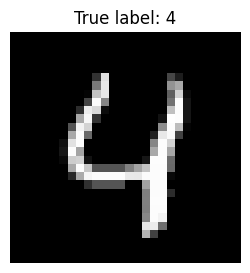

In [4]:
true_label = 4
n_pixels = 28 * 28


def get_first_image_with_label(dataset, label):
    for image, lbl in dataset:
        if lbl == label:
            return image
    return None


true_image_tensor = get_first_image_with_label(test_dataset, true_label)
true_image_flat = true_image_tensor.view(-1)
true_image = {i: float(true_image_flat[i]) for i in range(n_pixels)}

plt.figure(figsize=(3, 3))
plt.imshow(true_image_tensor.squeeze(0), cmap="gray")
plt.title(f"True label: {true_label}")
plt.axis("off")
plt.show()

## The Original Prediction Set

Before perturbing anything, we check which classes the calibrated classifier already
includes in the prediction set for this image.


In [5]:
with torch.no_grad():
    true_logits = model(true_image_tensor.unsqueeze(0)).squeeze(0)

original_set = torch.nonzero(-true_logits <= q_logit, as_tuple=True)[0].tolist()
print(f"Original prediction set: {original_set}")
print(f"True label {true_label} in set: {true_label in original_set}")

Original prediction set: [4, 9]
True label 4 in set: True


## Embedding the Classifier in Pyomo with OMLT

We export the trained PyTorch classifier to ONNX and load it into OMLT, then define a
helper that builds a fresh Pyomo model with the classifier embedded via
`ReluBigMFormulation`, an L1-distance objective to the original image, and pixel bounds
$[0, 1]^{784}$. Each example below adds its own extra constraints on top of this base
model.


In [6]:
# MnistClassifier flattens internally (x.view(...)); ONNX tracing turns that into a
# Reshape node driven by the dynamic batch size, which OMLT's parser cannot consume.
# This thin wrapper reuses the trained layers but expects already-flat input, so the
# traced graph has no internal reshape.
class FlatClassifier(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base

    def forward(self, x):
        x = torch.relu(self.base.fc1(x))
        x = torch.relu(self.base.fc2(x))
        x = torch.relu(self.base.fc3(x))
        x = torch.relu(self.base.fc4(x))
        return self.base.fc_out(x)


export_model = FlatClassifier(model)
export_model.eval()

dummy_input = torch.randn(1, n_pixels)
input_bounds = [(0.0, 1.0) for _ in range(n_pixels)]

with tempfile.NamedTemporaryFile(suffix=".onnx", delete=False) as f:
    torch.onnx.export(
        export_model,
        dummy_input,
        f.name,
        input_names=["input"],
        output_names=["output"],
        dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
        dynamo=False,
    )
    write_onnx_model_with_bounds(f.name, None, input_bounds)
    network_definition = load_onnx_neural_network_with_bounds(f.name)


def build_l1_model(network_definition, true_image):
    m = pyo.ConcreteModel()
    m.IN = pyo.Set(initialize=range(n_pixels))
    m.OUT = pyo.Set(initialize=range(10))

    m.x = pyo.Var(m.IN, bounds=(0, 1))
    m.y = pyo.Var(m.OUT)
    m.true_image = pyo.Param(m.IN, initialize=true_image)

    m.nn = OmltBlock()
    formulation = ReluBigMFormulation(network_definition)
    m.nn.build_formulation(formulation)

    @m.Constraint(m.IN)
    def connect_inputs(m, i):
        return m.x[i] == m.nn.inputs[i]

    @m.Constraint(m.OUT)
    def connect_outputs(m, j):
        return m.y[j] == m.nn.outputs[j]

    # L1-distance objective: minimize the perturbation to the original image
    m.xabs = pyo.Var(m.IN, bounds=(0, 1))

    @m.Constraint(m.IN)
    def xabs_pos(m, i):
        return m.xabs[i] >= m.x[i] - m.true_image[i]

    @m.Constraint(m.IN)
    def xabs_neg(m, i):
        return m.xabs[i] >= m.true_image[i] - m.x[i]

    @m.Objective(sense=pyo.minimize)
    def l1_distance(m):
        return sum(m.xabs[i] for i in m.IN)

    return m


def plot_perturbation(true_image, pixel_dict, title):
    image1 = np.array(list(true_image.values())).reshape(28, 28)
    image2 = np.array(list(pixel_dict.values())).reshape(28, 28)
    noise = np.abs(image2 - image1)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes[0].imshow(image1, cmap="gray")
    axes[0].set_title("True Image")
    axes[1].imshow(image2, cmap="gray")
    axes[1].set_title(title)
    im = axes[2].imshow(noise, cmap="magma", vmin=0, vmax=0.2)
    axes[2].set_title("|Noise|")
    for ax in axes:
        ax.axis("off")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    plt.show()

/tmp/ipykernel_28646/2693580099.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


## Getting a Valid Big-M Directly From OMLT

When `ReluBigMFormulation` builds the network, it propagates the input bounds
$[0, 1]^{784}$ through every layer and stores the resulting bounds on each layer's
internal variables. We can read off the bounds OMLT computed for the **output** layer
(the logits) directly from the block, and use them as $M_k$ in the formulation above.


In [7]:
def get_output_bounds(m):
    """Read the logit bounds OMLT computed internally for the output layer.

    OMLT constructs `m.nn.layers` in network order, so the last entry is always the
    output layer for this simple sequential architecture.
    """
    output_layer_id = list(m.nn.layers)[-1]
    return {k: m.nn.layer[output_layer_id].z[k].bounds for k in m.OUT}


m_bounds = build_l1_model(network_definition, true_image)
output_bounds = get_output_bounds(m_bounds)

# A valid M_k for class k is the largest magnitude its logit can possibly reach. Each
# example below rebuilds the model and recomputes M_k so it stays self-contained.
M_k = {k: max(abs(lb), abs(ub)) for k, (lb, ub) in output_bounds.items()}

for k, (lb, ub) in output_bounds.items():
    print(f"class {k}: logit in [{lb:.1f}, {ub:.1f}], M_k = {M_k[k]:.1f}")

class 0: logit in [-4217.7, 4331.1], M_k = 4331.1
class 1: logit in [-13011.0, 10382.6], M_k = 13011.0
class 2: logit in [-6747.0, 6878.7], M_k = 6878.7
class 3: logit in [-5587.5, 8215.9], M_k = 8215.9
class 4: logit in [-11383.5, 6449.5], M_k = 11383.5
class 5: logit in [-4455.6, 7436.9], M_k = 7436.9
class 6: logit in [-14600.0, 6318.2], M_k = 14600.0
class 7: logit in [-13741.7, 10247.7], M_k = 13741.7
class 8: logit in [-5978.3, 6376.3], M_k = 6376.3
class 9: logit in [-5489.7, 7457.7], M_k = 7457.7


## Example 1: Fooling the Classifier With Any Label

Rather than targeting one specific alternate label, we ask the more natural question:
how much perturbation is needed to fool the classifier with **any** wrong label? We
compare two variants:

(a) **Standard**: the true label must stop being the top-1 prediction, i.e., at least one
other class's logit must (slightly) exceed it. This uses no information from calibration.

(b) **Uncertainty-aware**: using the formulation above with
$\mathcal{K}^{\text{und}} = \{4\}$ and $\mathcal{K}^{\text{des}}$ equal to every other
class, the true label must leave the prediction set while at least one other class
enters it.

Because excluding the true label from a calibrated set requires crossing the fixed margin
$\widehat{q}_{1-\alpha}$, while (a) only requires crossing a margin of zero between two
logits, (b) is a structurally stronger condition than (a) by construction, regardless of
what we observe empirically.


Solver status: optimal
L1 perturbation (a) standard, any label: 0.0530


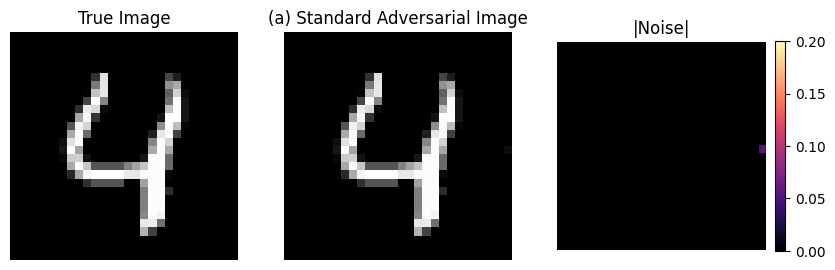

In [8]:
m1a = build_l1_model(network_definition, true_image)
m1a.z = pyo.Var(m1a.OUT, within=pyo.Binary)

alt_labels = [k for k in range(10) if k != true_label]
output_bounds_1a = get_output_bounds(m1a)


@m1a.Constraint(alt_labels)
def flip_to_alt(m, k):
    # valid big-M for "y_k - y_true >= epsilon": true's logit at its highest minus
    # k's logit at its lowest is the most this constraint could ever need to relax by
    _, ub_true = output_bounds_1a[true_label]
    lb_k, _ = output_bounds_1a[k]
    m_diff = ub_true - lb_k
    return m.y[k] - m.y[true_label] >= epsilon - m_diff * (1 - m.z[k])


@m1a.Constraint()
def at_least_one_alt(m):
    return sum(m.z[k] for k in alt_labels) >= 1


cbc = pyo.SolverFactory("cbc")
results = cbc.solve(m1a, tee=False)

distance_standard = pyo.value(m1a.l1_distance)
print(f"Solver status: {results.solver.termination_condition}")
print(f"L1 perturbation (a) standard, any label: {distance_standard:.4f}")

plot_perturbation(true_image, m1a.x.extract_values(), "(a) Standard Adversarial Image")

Solver status: optimal
L1 perturbation (b) uncertainty-aware, any label: 0.1784
Ratio to standard perturbation: 3.37x


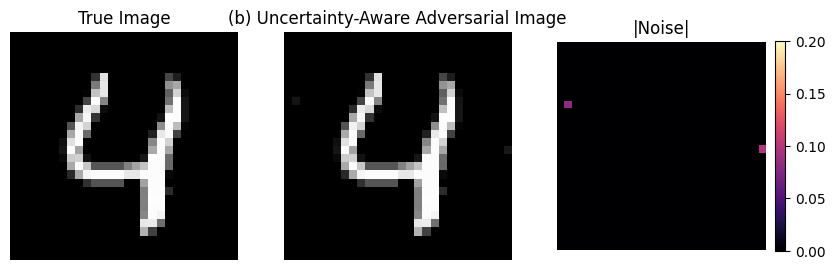

In [9]:
m1b = build_l1_model(network_definition, true_image)
m1b.w = pyo.Var(m1b.OUT, within=pyo.Binary)

K_und = {true_label}
K_des = set(range(10)) - K_und

output_bounds_1b = get_output_bounds(m1b)
M_k_1b = {k: max(abs(lb), abs(ub)) for k, (lb, ub) in output_bounds_1b.items()}


@m1b.Constraint(m1b.OUT)
def indicator_upper(m, k):
    return -m.y[k] - q_logit <= M_k_1b[k] * (1 - m.w[k])


@m1b.Constraint(m1b.OUT)
def indicator_lower(m, k):
    return m.y[k] + q_logit + epsilon <= M_k_1b[k] * m.w[k]


@m1b.Constraint()
def at_least_one_desired(m):
    return sum(m.w[k] for k in K_des) >= 1


for k in K_und:
    m1b.w[k].fix(0)

results = cbc.solve(m1b, tee=False)

distance_aware = pyo.value(m1b.l1_distance)
print(f"Solver status: {results.solver.termination_condition}")
print(f"L1 perturbation (b) uncertainty-aware, any label: {distance_aware:.4f}")
print(f"Ratio to standard perturbation: {distance_aware / distance_standard:.2f}x")

plot_perturbation(
    true_image, m1b.x.extract_values(), "(b) Uncertainty-Aware Adversarial Image"
)

## Discussion

The standard model's top-1 prediction is fooled with very little perturbation, while
removing the true label from the calibrated prediction set takes substantially more, as
the printed ratio above shows. Embedding uncertainty quantification directly into the
optimization model raises the cost of fooling it, making a verification procedure built
on the uncertainty-aware formulation more robust than one built on the standard model
alone.


## Bonus Example: Manipulating the Prediction Set Directly

The $\mathcal{K}^{\text{des}}/\mathcal{K}^{\text{und}}$ sets are not limited to "one
specific label" or "every other label": they can be any group, with any membership
requirement, we choose. As a further illustration, we pick five wrong labels,
$\mathcal{K}^{\text{des}} = \{0, 1, 2, 3, 5\}$, and ask how much perturbation is needed
so that **all five** of them enter the prediction set simultaneously
($w_k = 1$ for every $k \in \mathcal{K}^{\text{des}}$), with
$\mathcal{K}^{\text{und}} = \{4\}$ excluded as before.


Solver status: optimal
L1 perturbation (all of {0,1,2,3,5} in the set): 0.8007
Resulting prediction set membership: {0: 1, 1: 1, 2: 1, 3: 1, 4: 0, 5: 1, 6: 1, 7: 0, 8: 0, 9: 0}


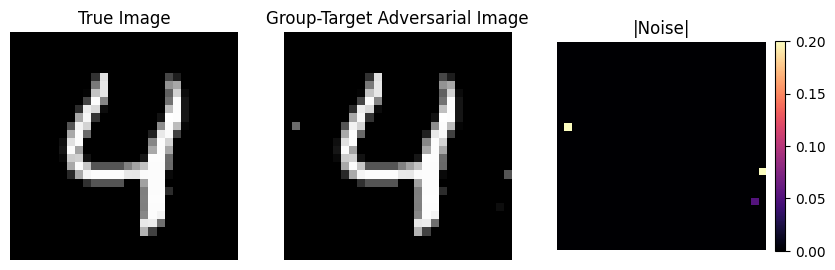

In [10]:
m_bonus = build_l1_model(network_definition, true_image)
m_bonus.w = pyo.Var(m_bonus.OUT, within=pyo.Binary)

K_und_bonus = {true_label}
K_des_bonus = {0, 1, 2, 3, 5}

output_bounds_bonus = get_output_bounds(m_bonus)
M_k_bonus = {k: max(abs(lb), abs(ub)) for k, (lb, ub) in output_bounds_bonus.items()}


@m_bonus.Constraint(m_bonus.OUT)
def indicator_upper(m, k):
    return -m.y[k] - q_logit <= M_k_bonus[k] * (1 - m.w[k])


@m_bonus.Constraint(m_bonus.OUT)
def indicator_lower(m, k):
    return m.y[k] + q_logit + epsilon <= M_k_bonus[k] * m.w[k]


# require every desired label to be admitted, not just one of them; other
# classes are left free and may end up admitted too as a side effect
for k in K_des_bonus:
    m_bonus.w[k].fix(1)

for k in K_und_bonus:
    m_bonus.w[k].fix(0)

results = cbc.solve(m_bonus, tee=False)

distance_bonus = pyo.value(m_bonus.l1_distance)
w_values = {k: round(pyo.value(m_bonus.w[k])) for k in m_bonus.OUT}

print(f"Solver status: {results.solver.termination_condition}")
print(f"L1 perturbation (all of {{0,1,2,3,5}} in the set): {distance_bonus:.4f}")
print(f"Resulting prediction set membership: {w_values}")

plot_perturbation(
    true_image, m_bonus.x.extract_values(), "Group-Target Adversarial Image"
)

Requiring all five labels at once costs more than requiring just one, the same
pattern as Example 1: the stronger the requirement on the prediction set, the more
perturbation it takes to satisfy.


## Citation

If this notebook was useful to your work, please cite:

```bibtex
@article{ovalle2026conformal,
  title={Conformal Mixed-Integer Constraint Learning with Feasibility Guarantees},
  author={Ovalle, Daniel and Biegler, Lorenz and Grossmann, Ignacio and Laird, Carl and Dulce Rubio, Mateo},
  journal={Advances in Neural Information Processing Systems},
  volume={38},
  pages={80387--80423},
  year={2026}
}
```
